### Introduction

Principal Component Analysis (PCA) is a concept that many people find challenging to understand (including myself), especially when first introduced. It’s often explained using a lot of complex math, which can make it feel more confusing than it needs to be.

In this notebook, I’ll take a practical and step-by-step approach to understanding PCA. Instead of relying on pre-built libraries, I’ll create a PCA algorithm from scratch to see exactly how it works. Along the way, we’ll explore the key ideas behind PCA, like variance and eigenvectors, and learn why they’re important in reducing the complexity of data.

The goal is to make PCA feel more approachable and give you a solid understanding of what’s happening behind the scenes.

### A good question to ask here is, why do we use PCA?

It’s helpful when:

- Your dataset has too many features (dimensions), making it hard to analyze.
  
- You want to simplify the data while keeping the important patterns.

- You need to visualize high-dimensional data in 2D or 3D.

- PCA reduces complexity without losing the essence of the data, making it a powerful tool for simplifying and understanding big datasets.

### Some videos to watch before trying to understand what is happening behind the PCA algorithm:


- Good to know how eigen-dudes are calculated - https://www.youtube.com/watch?v=TQvxWaQnrqI&t=3s


- Good to know what PCA does - *** warning *** - Super boring video - https://www.youtube.com/watch?v=dz8imS1vwIM&t=1112s

### Isabelle proudly presents - PCA from Scratch

Step-by-Step Implementation
1. Standardize the Data:

Center the data (mean = 0) and scale it (standard deviation = 1).

2. Compute the Covariance Matrix:

Calculate the covariance matrix to understand how the features vary together.

3. Calculate Eigenvalues and Eigenvectors:

Compute the eigenvalues and eigenvectors of the covariance matrix.

4. Sort Eigenvalues and Eigenvectors:

Sort the eigenvalues and their corresponding eigenvectors in descending order.

5. Select Principal Components:

Choose the top 
𝑘
k eigenvectors to form the principal components.

6. Transform the Data:

Project the original data onto the new feature space defined by the principal components.

In [1]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example usage with sklearn datasets
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer


In [2]:
# This dataset is a good candidate to test the PCA algoritm as there are 30 columns in this dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
# I would like to check some descriptive stats - Features have different value ranges so this would be a good candidate for standardization

X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [4]:
# Let's do a pairplot to see how features are distributed as well as some underlying relationships against each other - it is a very large plot so I will comment out the output due to size restrictions
#sns.pairplot(data = X)
#plt.show()

In [5]:
# This was a good way to see how some of the features are correlated, the direction of their relationshop without even calculating the correlations, below is a correclation heatmap which would also give us some ideas of how the features are correlated.

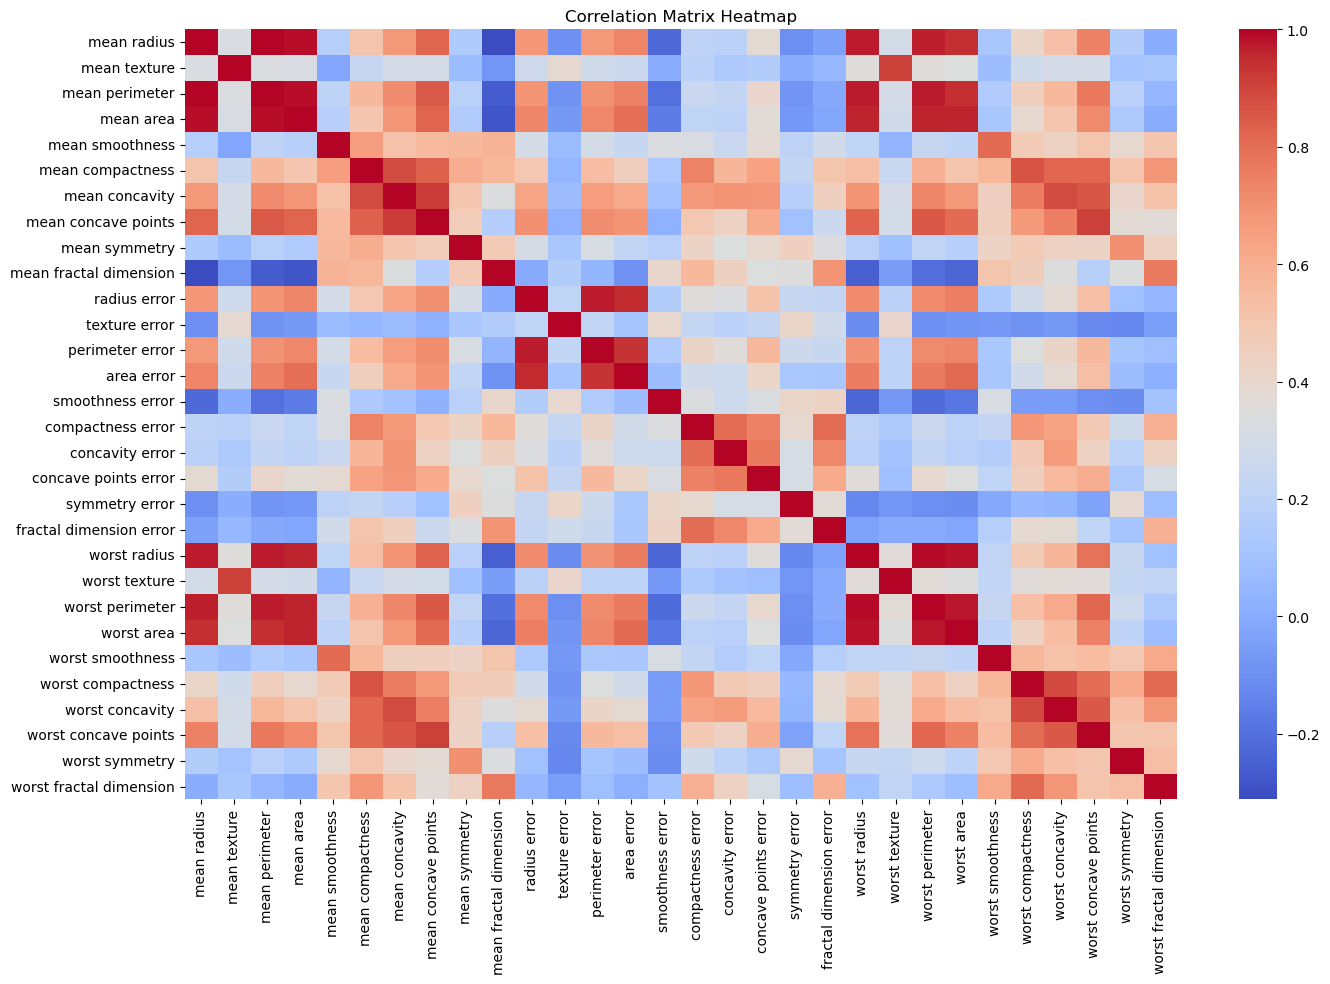

In [6]:
plt.figure(figsize=(16, 10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False, fmt=".2f") # Changing annot=False to True will display the numeric values
plt.title('Correlation Matrix Heatmap')
plt.show()

In [7]:
# Let's start!

In [8]:
# Below step will scale the data which will be then used in the covariance matrix calculation. We standardize the data because;

# Covariance matrix: Measures the relationship between features, but is scale-sensitive.
# Correlation matrix: Measures the relationship between features, but normalizes for scale, making it more suitable when features have different magnitudes or units. 

# We could alternatively use .corr() function

In [9]:
# Step 1: Standardize the data

# Standardization ensures that all features contribute equally to the analysis by rescaling them to have a mean of 0 and a standard deviation of 1.

def standardize_data(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std

In [10]:
# Let's try the function
Xs = standardize_data(X)

In [11]:
# Step 2: Compute the covariance matrix

# Calculating the covariance matrix is a critical step in PCA because it captures the relationships between features in the dataset. It shows how much two features vary together (covariance) across the dataset.

    # Positive covariance indicates that two features increase or decrease together, while negative covariance means one increases as the other decreases.
    # Features with zero covariance are independent of each other.

# High covariances (off-diagonal values in the covariance matrix) suggest redundancy in the dataset, meaning some features convey similar information.

# PCA uses this information to combine correlated features into a single principal component, reducing redundancy.

def compute_covariance_matrix(Xstandard):
    n_samples = Xstandard.shape[0]
    return np.dot(Xstandard.T, Xstandard) / (n_samples - 1)

In [12]:
cov_matrix = compute_covariance_matrix(Xs) # This creates a 30 x 30 covariance matrix
cov_matrix

array([[ 1.00176056e+00,  3.24351929e-01,  9.99612069e-01,
         9.89095475e-01,  1.70881506e-01,  5.07014640e-01,
         6.77955036e-01,  8.23976636e-01,  1.48001350e-01,
        -3.12179472e-01,  6.80285970e-01, -9.74887767e-02,
         6.75358538e-01,  7.37159198e-01, -2.22992026e-01,
         2.06362656e-01,  1.94545531e-01,  3.76831225e-01,
        -1.04504545e-01, -4.27163418e-02,  9.71245907e-01,
         2.97530545e-01,  9.66835698e-01,  9.42739295e-01,
         1.19826732e-01,  4.14190751e-01,  5.27839123e-01,
         7.45524434e-01,  1.64241985e-01,  7.07832563e-03],
       [ 3.24351929e-01,  1.00176056e+00,  3.30113223e-01,
         3.21650988e-01, -2.34296930e-02,  2.37118951e-01,
         3.02950254e-01,  2.93980713e-01,  7.15266864e-02,
        -7.65717560e-02,  2.76354360e-01,  3.87037830e-01,
         2.82169018e-01,  2.60302460e-01,  6.62542133e-03,
         1.92312595e-01,  1.43545353e-01,  1.64139495e-01,
         9.14323671e-03,  5.45533955e-02,  3.53193674e-

In [13]:
# Step 3: Calculate eigenvalues and eigenvectors

# Calculating eigenvalues and eigenvectors is a pivotal step in PCA because it helps identify the principal components, which are the new axes that maximize variance in the data.

# 1. Eigenvalues Measure Variance in Principal Components
    # Eigenvalues represent the amount of variance captured along each principal component (PC).
    # Larger eigenvalues indicate components that explain more variance in the data.
    # PCA uses eigenvalues to rank the principal components by their importance (variance captured).

# 2. Eigenvectors Define the Directions of Principal Components
    # Eigenvectors are the directions or axes corresponding to the eigenvalues.
    # Each eigenvector represents a principal component, which is a linear combination of the original features.
    # These directions are orthogonal (uncorrelated), ensuring that the principal components are independent of one another.

def compute_eigenvalues_and_eigenvectors(cov_matrix):
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    return eigenvalues, eigenvectors

In [14]:
eigenvalues, eigenvectors = compute_eigenvalues_and_eigenvectors(cov_matrix) # This will now calculate the eigenvalues and eigenvectors, I will only print the shapes of them
eigenvalues.shape, eigenvectors.shape

((30,), (30, 30))

In [15]:
eigenvalues

array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
       1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
       4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
       2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
       5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 1.33279057e-04,
       7.50121413e-04, 1.59213600e-03, 6.91261258e-03, 8.19203712e-03,
       1.55085271e-02, 1.80867940e-02, 2.43836914e-02, 2.74877113e-02,
       3.12142606e-02, 3.00256631e-02])

In [16]:
# Step 4: Sort eigenvalues and eigenvectors

# Sorting the eigenvalues and eigenvectors in PCA ensures that you are focusing on the most significant components, both in terms of variance and direction. This is crucial for dimensionality reduction, preserving the most important information, and simplifying the dataset for further analysis or visualization.

def sort_eigenvalues_and_eigenvectors(eigenvalues, eigenvectors):
    idx = eigenvalues.argsort()[::-1]
    sorted_eigenvalues = eigenvalues[idx]
    sorted_eigenvectors = eigenvectors[:, idx]
    return sorted_eigenvalues, sorted_eigenvectors

In [17]:
sorted_eigenvalues, sorted_eigenvectors = sort_eigenvalues_and_eigenvectors(eigenvalues, eigenvectors) # This will now sort the eigenvalues and eigenvectors from highest to lowest values so the PCA algorthm can use the highest variance explained 
sorted_eigenvalues, sorted_eigenvectors

(array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
        1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
        4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
        2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
        5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 3.12142606e-02,
        3.00256631e-02, 2.74877113e-02, 2.43836914e-02, 1.80867940e-02,
        1.55085271e-02, 8.19203712e-03, 6.91261258e-03, 1.59213600e-03,
        7.50121413e-04, 1.33279057e-04]),
 array([[ 2.18902444e-01, -2.33857132e-01, -8.53124284e-03,
          4.14089623e-02, -3.77863538e-02,  1.87407904e-02,
          1.24088340e-01,  7.45229622e-03, -2.23109764e-01,
          9.54864432e-02,  4.14714866e-02,  5.10674568e-02,
          1.19672116e-02, -5.95061348e-02, -5.11187749e-02,
          1.50583883e-01, -2.02924255e-01, -1.46712338e-01,
          2.25384659e-01, -4.96986642e-02,  6.85700057e-02,
         -7.29289034e-02,  9.85526

In [18]:
# Step 5: Select top k eigenvectors (principal components)

# By selecting the top k eigenvectors, you are ensuring that you are keeping the directions that capture the most important features of the data, discarding the less important directions that correspond to smaller eigenvalues (and lower variance).

#This helps in preserving the essential structure of the data, while eliminating noise and less informative dimensions.

def select_top_k_eigenvectors(s_eigenvectors, k):
    return eigenvectors[:, :k]

In [19]:
eigenvectorsTop5 = select_top_k_eigenvectors(sorted_eigenvectors, 5)
eigenvectorsTop5, eigenvectorsTop5.shape

(array([[ 0.21890244, -0.23385713, -0.00853124,  0.04140896, -0.03778635],
        [ 0.10372458, -0.05970609,  0.0645499 , -0.60305   ,  0.04946885],
        [ 0.22753729, -0.21518136, -0.00931422,  0.0419831 , -0.03737466],
        [ 0.22099499, -0.23107671,  0.02869953,  0.0534338 , -0.01033125],
        [ 0.14258969,  0.18611302, -0.1042919 ,  0.15938277,  0.36508853],
        [ 0.23928535,  0.15189161, -0.07409157,  0.03179458, -0.01170397],
        [ 0.25840048,  0.06016536,  0.00273384,  0.01912275, -0.08637541],
        [ 0.26085376, -0.0347675 , -0.02556354,  0.06533594,  0.04386103],
        [ 0.13816696,  0.19034877, -0.04023994,  0.06712498,  0.30594143],
        [ 0.06436335,  0.36657547, -0.02257409,  0.04858676,  0.04442436],
        [ 0.20597878, -0.10555215,  0.26848139,  0.09794124,  0.1544565 ],
        [ 0.01742803,  0.08997968,  0.37463367, -0.35985553,  0.19165051],
        [ 0.21132592, -0.08945723,  0.26664537,  0.08899241,  0.12099022],
        [ 0.20286964, -0.

In [20]:
# for demonstration, we will be selecting the first column of the array. This column represents the contributions of all features to the first eigenvector and show it in a bar chart
eigenvectorsTop5[:,0] 

array([0.21890244, 0.10372458, 0.22753729, 0.22099499, 0.14258969,
       0.23928535, 0.25840048, 0.26085376, 0.13816696, 0.06436335,
       0.20597878, 0.01742803, 0.21132592, 0.20286964, 0.01453145,
       0.17039345, 0.15358979, 0.1834174 , 0.04249842, 0.10256832,
       0.22799663, 0.10446933, 0.23663968, 0.22487053, 0.12795256,
       0.21009588, 0.22876753, 0.25088597, 0.12290456, 0.13178394])

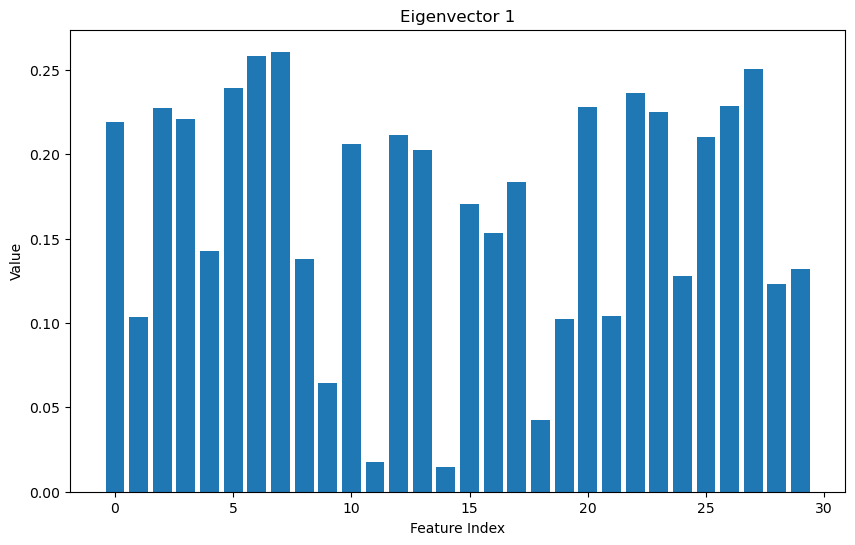

In [21]:
# Bar chart visualization of a specific eigenvector, which highlights the contribution of each feature (or variable) to that eigenvector. In our case I am just testing it for the first eigenvector, different eigenvectors would return different bar chart representations
eigenvector_index = 0  # First eigenvector being tested
plt.figure(figsize=(10, 6))
plt.bar(range(len(eigenvectorsTop5[:, eigenvector_index])), eigenvectorsTop5[:, eigenvector_index])
plt.title(f"Eigenvector {eigenvector_index + 1}")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.show()

In [22]:
# Similar to above, now want to visualize the second eigenvector column
eigenvectorsTop5[:,1]

array([-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
        0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
       -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
        0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
       -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
        0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947])

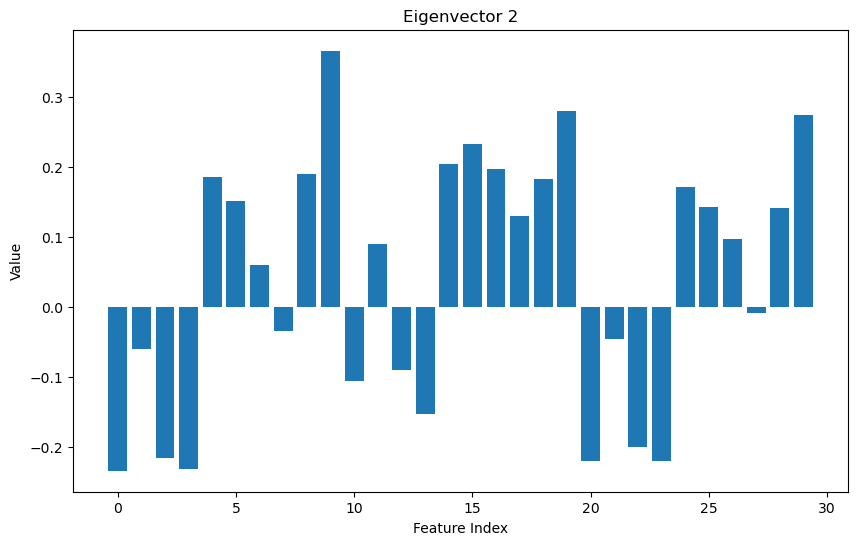

In [23]:
eigenvector_index = 1  # Second eigenvector being tested
plt.figure(figsize=(10, 6))
plt.bar(range(len(eigenvectorsTop5[:, eigenvector_index])), eigenvectorsTop5[:, eigenvector_index])
plt.title(f"Eigenvector {eigenvector_index + 1}")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.show()

In [24]:
# Step 6: Transform the data

# This step reduces the dimensionality of the data, preserves the most important variance, and simplifies the data for further analysis, modeling, or visualization. 

def transform_data(Xstandard, topK_eigenvectors):
    return np.dot(Xstandard, topK_eigenvectors)

In [25]:
transform_data(Xs, eigenvectorsTop5)

transform_data(Xs, eigenvectorsTop5).shape

(569, 5)

In [26]:
# Cumulative variance explained plot

# This plot helps decide how many principal components to keep when performing dimensionality reduction. You can choose a number of components that explains a satisfactory proportion of variance (e.g., 90% or 95% of the variance), reducing the dimensionality of the dataset without losing much information.

def plot_cumulative_variance_explained(sorted_eigenvalues, num_components=None):
    """
    Plots the cumulative variance explained by principal components.
    
    Parameters:
    - eigenvalues (array-like): Sorted eigenvalues representing the variance explained by components.
    - num_components (int, optional): Number of components to display in the plot. Defaults to all components.
    """
    total_variance = np.sum(eigenvalues)
    explained_variances = eigenvalues / total_variance
    cumulative_explained_variances = np.cumsum(explained_variances)

    # Determine the range to plot
    if num_components is None or num_components > len(eigenvalues):
        num_components = len(eigenvalues)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_components + 1), cumulative_explained_variances[:num_components], 
             marker='o', linestyle='--', color='b')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Variance Explained by Principal Components')
    plt.grid(True)
    plt.xticks(range(1, num_components + 1))  # Ensure x-axis ticks align with the number of components
    plt.show()


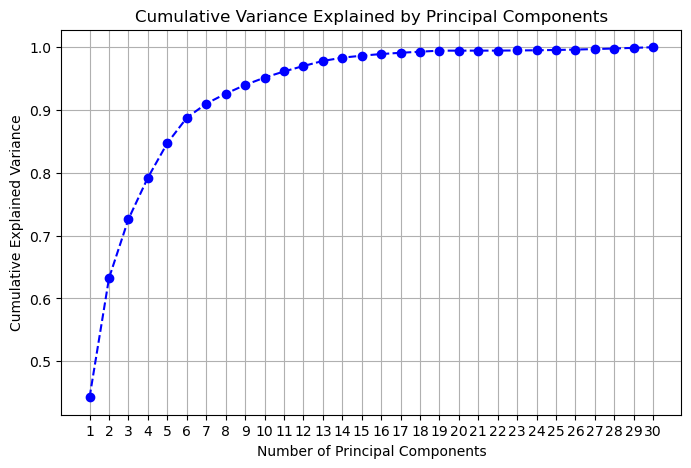

In [27]:
plot_cumulative_variance_explained(sorted_eigenvalues)

In [28]:
# Main PCA function which combines all the mini functions that I created above to demonstrate what happens in a PCA algorithm

def pca(X, k):
    X_standardized = standardize_data(X)
    cov_matrix = compute_covariance_matrix(X_standardized)
    eigenvalues, eigenvectors = compute_eigenvalues_and_eigenvectors(cov_matrix)
    sorted_eigenvalues, sorted_eigenvectors = sort_eigenvalues_and_eigenvectors(eigenvalues, eigenvectors)
    top_k_eigenvectors = select_top_k_eigenvectors(sorted_eigenvectors, k)
    X_pca = transform_data(X_standardized, top_k_eigenvectors)
    return X_pca, sorted_eigenvalues, sorted_eigenvectors

In [29]:
# I will re-load this dataset, just to be sure that we have a fresh start in order to apply the pca function on a new dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [30]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [31]:
# Perform PCA, reducing to 10 principal components
X_pca, sorted_eigenvalues, sorted_eigenvectors = pca(X, 5)



In [32]:
print("Transformed Data (First 10 samples):")
print(X_pca[:10])


Transformed Data (First 10 samples):
[[ 9.19283683  1.94858307 -1.12316616  3.6337309   1.19511012]
 [ 2.3878018  -3.76817174 -0.52929269  1.11826386 -0.62177498]
 [ 5.73389628 -1.0751738  -0.55174759  0.91208267  0.1770859 ]
 [ 7.1229532  10.27558912 -3.23278955  0.15254703  2.9608784 ]
 [ 3.93530207 -1.94807157  1.38976673  2.94063935 -0.5467474 ]
 [ 2.38024715  3.9499289  -2.93487679  0.94103687  1.05604193]
 [ 2.23888331 -2.69003128 -1.63991293  0.14933989 -0.04035952]
 [ 2.1432985   2.34024401 -0.87194726 -0.12704286  1.42743667]
 [ 3.17492429  3.39181295 -3.11998591 -0.60129705  1.52229039]
 [ 6.35174679  7.72717407 -4.34191581 -3.37520158 -1.71026314]]


In [33]:
print("Eigenvalues:")
print(sorted_eigenvalues)


Eigenvalues:
[1.33049908e+01 5.70137460e+00 2.82291016e+00 1.98412752e+00
 1.65163324e+00 1.20948224e+00 6.76408882e-01 4.77456255e-01
 4.17628782e-01 3.51310875e-01 2.94433153e-01 2.61621161e-01
 2.41782421e-01 1.57286149e-01 9.43006956e-02 8.00034045e-02
 5.95036135e-02 5.27114222e-02 4.95647002e-02 3.12142606e-02
 3.00256631e-02 2.74877113e-02 2.43836914e-02 1.80867940e-02
 1.55085271e-02 8.19203712e-03 6.91261258e-03 1.59213600e-03
 7.50121413e-04 1.33279057e-04]


In [34]:
print("Eigenvectors (First 5 components):")
print(sorted_eigenvectors[:, :5])

Eigenvectors (First 5 components):
[[ 0.21890244 -0.23385713 -0.00853124  0.04140896 -0.03778635]
 [ 0.10372458 -0.05970609  0.0645499  -0.60305     0.04946885]
 [ 0.22753729 -0.21518136 -0.00931422  0.0419831  -0.03737466]
 [ 0.22099499 -0.23107671  0.02869953  0.0534338  -0.01033125]
 [ 0.14258969  0.18611302 -0.1042919   0.15938277  0.36508853]
 [ 0.23928535  0.15189161 -0.07409157  0.03179458 -0.01170397]
 [ 0.25840048  0.06016536  0.00273384  0.01912275 -0.08637541]
 [ 0.26085376 -0.0347675  -0.02556354  0.06533594  0.04386103]
 [ 0.13816696  0.19034877 -0.04023994  0.06712498  0.30594143]
 [ 0.06436335  0.36657547 -0.02257409  0.04858676  0.04442436]
 [ 0.20597878 -0.10555215  0.26848139  0.09794124  0.1544565 ]
 [ 0.01742803  0.08997968  0.37463367 -0.35985553  0.19165051]
 [ 0.21132592 -0.08945723  0.26664537  0.08899241  0.12099022]
 [ 0.20286964 -0.15229263  0.21600653  0.10820504  0.12757443]
 [ 0.01453145  0.20443045  0.30883898  0.04466418  0.23206568]
 [ 0.17039345  0.232

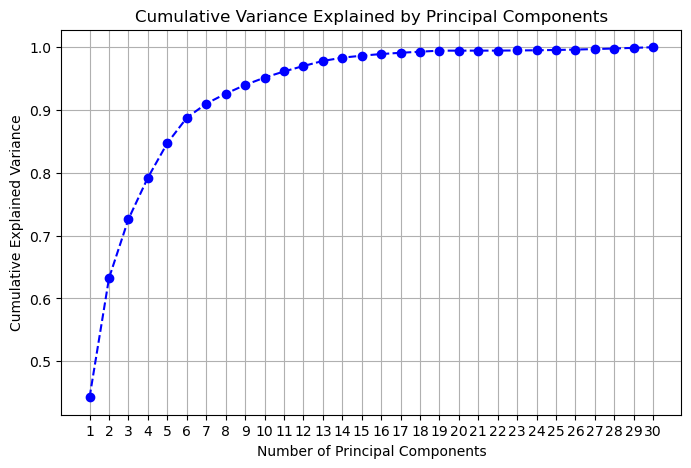

In [35]:
plot_cumulative_variance_explained(sorted_eigenvalues)

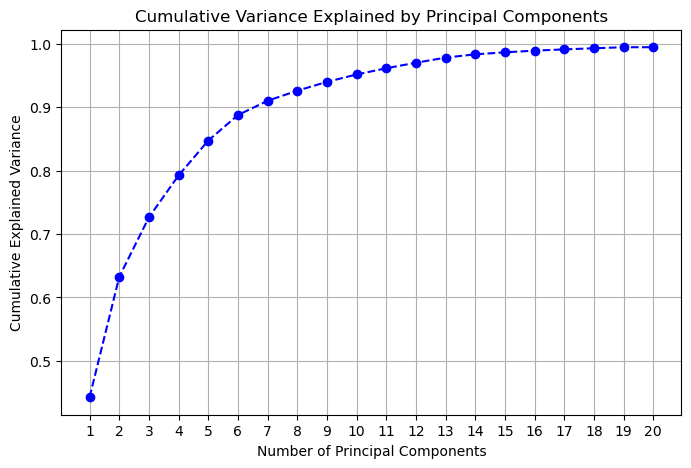

In [36]:
plot_cumulative_variance_explained(sorted_eigenvalues, 20) # Would like to plot it just for the forst 20 principe components

In [37]:
# So from what we see above,
# In our breast cancer data with 30 initial columns/features;

    # 1. around 40% of the variance is explained by just 1 component, 
    # 2. also, after the first 16 components, explained varience plateaus, meaning using all 30 features in a model will perform exactly the same selecting the first 16 PCA'd features.